# ĐỒ ÁN: TIỀN XỬ LÍ DỮ LIỆU
1. Task 1: Loại bỏ các cột mà nhóm nghĩ là không cần thiết:

Ở phần EDA, ta đã phát hiện được các cột chứa giá trị không cần thiết cho quá trình train model
- Item Table
+ 'gender_target' 65% NULL -> Tùy bài toán mới xác định giữ hay drop

Tùy bài toán thì mới loại bỏ những cột không mang lại giá trị thông tin gì cho quá trình phân tích và huấn luyện mô hình (không giúp phân biệt hay giải thích sự khác biệt giữa các mẫu dữ liệu, nếu giữ lại sẽ làm tăng độ nhiễu cũng như kích thước dữ liệu không cần thiết).


In [6]:
import polars as pl
import glob
import pandas as pd

# Load Items data
items_df = pl.read_parquet('sales_pers.item_chunk_0.parquet')
print(f' Items: {items_df.shape[0]:,} rows × {items_df.shape[1]} columns')

# Load Users data
user_files = sorted(glob.glob('sales_pers.user_chunk_*.parquet'))
users_df = pl.read_parquet(user_files)
print(f' Users: {users_df.shape[0]:,} rows × {users_df.shape[1]} columns')

# Load Purchase History data
purchase_pattern = 'sales_pers.purchase_history_daily_chunk_*.parquet'

# Sử dụng scan_parquet cho lazy evaluation (tối ưu nhất)
purchases_df = pl.scan_parquet(purchase_pattern).collect()
print(f' Purchases: {purchases_df.shape[0]:,} rows × {purchases_df.shape[1]} columns')


 Items: 27,332 rows × 34 columns
 Users: 4,573,964 rows × 18 columns
 Purchases: 35,729,825 rows × 16 columns


2. Task 2: Loại bỏ NULL (Theo cách drop)

Ở phần EDA, ta đã phát hiện được các cột chứa giá trị không cần thiết cho quá trình train model
- User Table:
+ 'sync_status_id' khoảng 7,3% NULL
+ 'sync_error_message' 100% NULL
+ 'last_sync_date' khoảng 7% NULL
- Item Table
+ 'description' khoảng 68% NULL
+ 'brand' khoảng 20% NULL -> Giữ lại, không xác định vẫn có ý nghĩa
+ 'manufacturer' khoảng 94% NULL
+ 'sync_error_message' 100% NULL
+ 'image_url' 100% NULL
+ 'item_type' 35% NULL -> Giữ lại vì còn thông tin đủ để dùng
+ 'weight' 100% NULL 
+ 'color', 'size', 'origin', 'volume', 'material' 80% NULL
+ 'description_new' khoảng 65% NULL 

Ngoài những cột đã được đánh dấu thì những cột không mang lại giá trị thông tin gì cho quá trình phân tích và huấn luyện mô hình (không giúp phân biệt hay giải thích sự khác biệt giữa các mẫu dữ liệu, nếu giữ lại sẽ làm tăng độ nhiễu cũng như kích thước dữ liệu không cần thiết).

In [ ]:
# XÓA CÁC CỘT 100% NULL =
cols_to_drop = ['sync_error_message', 'image_url', 'weight', 'description', 'manufacturer']

def safe_drop(df, cols):
    # Lọc ra những cột thực sự tồn tại trong dataframe
    existing = [c for c in cols if c in df.columns]
    if existing:
        df = df.drop(existing)
        print(f"  Đã xóa các cột: {existing}")
    else:
        print("  Không có cột nào trong danh sách cần xóa tồn tại.")
    return df


# XÓA CÁC HÀNG NULL

def drop_null_rows(df, cols):
    """
    Xóa các hàng có giá trị NULL trong các cột chỉ định.
    Chỉ xóa nếu cột tồn tại trong dataframe.
    """
    existing_cols = [c for c in cols if c in df.columns]
    if not existing_cols:
        print(" Không có cột nào trong danh sách tồn tại trong DataFrame.")
        return df

    before = df.shape[0]
    df = df.drop_nulls(subset=existing_cols)
    after = df.shape[0]
    print(f" Đã xóa {before - after:,} hàng NULL trong các cột: {existing_cols}")
    return df

In [8]:
items_df = safe_drop(items_df, cols_to_drop)
users_df = safe_drop(users_df, cols_to_drop)

users_df = drop_null_rows(users_df, ["sync_status_id", "last_sync_date"])
items_df = drop_null_rows(items_df, ["color", "size", "origin", "volume", "material", "description_new"])

  Đã xóa các cột: ['sync_error_message', 'image_url', 'weight', 'description', 'manufacturer']
  Đã xóa các cột: ['sync_error_message']
 Đã xóa 338,285 hàng NULL trong các cột: ['sync_status_id', 'last_sync_date']
 Đã xóa 5,015 hàng NULL trong các cột: ['color', 'size', 'origin', 'volume', 'material', 'description_new']


2. Task 2: Xử lí NULL (Theo cách Fill)

Ở phần EDA, chúng ta đã phát hiện được rằng có 2 cột có chứa giá trị NULL đó là:

Trong Users Data:
+ Cột 'sync_status_id' có chứa 7,4% hàng chứa giá trị NaN, còn lại 92,6% hàng là giá trị 2.0
+ Cột 'last_sync_date' có chứa 7,4% hàng chứa giá trị NaT, còn lại là các giá trị date time trong đó 89,08% giá trị thuộc ngày 2025-07-16 (ngày xa nhất), 0,96% thuộc ngày 2025-07-20 (ngày gần nhất).

Trong Items Data:
+ Cột 'sync_status_id' có chứa 2.88% hàng chứa giá trị NaN, còn lại 97,12% hàng là giá trị 2.0
+ Cột 'last_sync_date' có chứa 2.88% hàng chứa giá trị NaT, còn lại là các giá trị date time trong đó 97,10% giá trị thuộc ngày 2025-07-18 (ngày xa nhất), 0,01% thuộc ngày 2025-07-20 (ngày gần nhất).

Lí do cần xử lí giá trị NULL
+ Đảm bảo tính toàn vẹn dữ liệu: Giá trị NULL có thể gây ra lỗi khi chạy các thuật toán học máy, tính toán thống kê hoặc khi thực hiện các phép biến đổi dữ liệu. Một số mô hình không chấp nhận giá trị thiếu.
+ Tránh thiên lệch kết quả: Dữ liệu NULL nếu không được xử lí có thể làm sai lệch kết quả phân tích. Ví dụ, khi tính tỉ lệ hoặc trung bình, các giá trị NULL có thể dẫn đến ước lượng không chính xác.
+ Cải thiện chất lượng dữ liệu: Việc xử lí NULL giúp dữ liệu đồng nhất, thuận tiện cho việc trực quan hóa, lập báo cáo và triển khai mô hình.

Hướng xử lí với dữ liệu phân bố hiện tại:
+ sync_status_id (Users và Items) : Hầu hết giá trị đều là 2.0 (92.6% cho Users, 97.12% cho Items), chỉ có một phần nhỏ là NULL.

=> Thay các giá trị NULL bằng giá trị phổ biến nhất (mode) là 2.0. (Khi tỉ lệ NULL nhỏ và dữ liệu phân bố đồng nhất, điền giá trị phổ biến sẽ không làm thay đổi phân bố dữ liệu.) 

+ last_sync_date (Users và Items): Phần lớn giá trị rơi vào một ngày cụ thể (89.08% là 2025-07-16 cho Users, 97.10% là 2025-07-18 cho Items).

=> Hướng xử lí tối ưu sẽ là điền NULL bằng giá trị phổ biến nhất (mode) cho cả hai cột sync_status_id và last_sync_date. Không cần loại bỏ hàng, vì số lượng NULL nhỏ và dữ liệu còn lại đã đồng nhất. Cách điền mode vừa đơn giản, vừa đảm bảo dữ liệu sạch và phân bố không bị thay đổi.






 

In [5]:
# --- Fill NULLs in Users ---

# sync_status_id: fill with mode (numeric)
users_sync_mode = users_df['sync_status_id'].mode()[0]
users_df = users_df.with_columns([
    pl.col('sync_status_id').fill_null(users_sync_mode)
])

# Lấy mode thực sự, loại bỏ NULL trước
users_last_sync_mode_series = users_df['last_sync_date'].drop_nulls().mode()
# Lấy giá trị đầu tiên (giá trị mode thực sự)
users_last_sync_mode = users_last_sync_mode_series[0]  
# Điền NULL bằng giá trị mode này
users_df = users_df.with_columns([
    pl.col('last_sync_date').fill_null(users_last_sync_mode)
])


In [6]:
# --- Fill NULLs in Items ---

# sync_status_id: fill with mode (numeric)
items_sync_mode = items_df['sync_status_id'].mode()[0]
items_df = items_df.with_columns([
    pl.col('sync_status_id').fill_null(items_sync_mode)
])

# last_sync_date: fill with mode (datetime)
# loại bỏ NULL trước khi tính mode
items_last_sync_mode_series = items_df['last_sync_date'].drop_nulls().mode()
items_last_sync_mode = items_last_sync_mode_series[0]  # giữ nguyên datetime với giờ, phút, giây

items_df = items_df.with_columns([
    pl.col('last_sync_date').fill_null(items_last_sync_mode)
])

In [7]:
#Kiểm tra dữ liệu sau khi xử lí

# Danh sách dataset cần phân tích
datasets = [("users_df", users_df), ("items_df", items_df)]

for name, df in datasets:
    print(f"\n{'='*80}")
    print(f" Dataset: {name}")

    # Kiểm tra cột cần thiết
    required_cols = {'last_sync_date', 'sync_status_id'}
    if not required_cols.issubset(df.columns):
        print(f" Bỏ qua {name}: thiếu một trong các cột {required_cols}.")
        continue

    # Nếu last_sync_date là string thì chuyển sang datetime
    if df['last_sync_date'].dtype == pl.Utf8:
        df = df.with_columns(
            pl.col("last_sync_date").str.to_datetime(strict=False)
        )

    # Chuyển sang pandas để thao tác
    pdf = df.to_pandas()

    # Chuẩn hóa dữ liệu ngày (chỉ lấy phần ngày)
    pdf['last_sync_date'] = pd.to_datetime(pdf['last_sync_date'], errors='coerce').dt.date

    # Tính tỷ lệ % cho từng giá trị trong cột sync_status_id (bao gồm cả null)
    sync_percent = pdf['sync_status_id'].value_counts(normalize=True, dropna=False) * 100
    print(f"\nTỷ lệ % giá trị trong cột 'sync_status_id' của {name}:")
    print(sync_percent.round(2).to_string())

    # Tính tỷ lệ % cho từng ngày trong cột last_sync_date (bao gồm cả null)
    date_percent = pdf['last_sync_date'].value_counts(normalize=True, dropna=False) * 100
    print(f"\nTỷ lệ % giá trị trong cột 'last_sync_date' của {name}:")
    print(date_percent.round(2).head(10).to_string())  # chỉ in 10 dòng đầu



 Dataset: users_df

Tỷ lệ % giá trị trong cột 'sync_status_id' của users_df:
sync_status_id
2    100.0

Tỷ lệ % giá trị trong cột 'last_sync_date' của users_df:
last_sync_date
2025-07-16    96.48
2025-07-18     1.44
2025-07-21     1.12
2025-07-20     0.96

 Dataset: items_df

Tỷ lệ % giá trị trong cột 'sync_status_id' của items_df:
sync_status_id
2    100.0

Tỷ lệ % giá trị trong cột 'last_sync_date' của items_df:
last_sync_date
2025-07-18    99.97
2025-07-21     0.02
2025-07-20     0.01


2. Task 2: Xử lí NULL, Outlier:
Ở phần EDA, chúng ta đã phát hiện được rằng có 2 cột chứa giá trị outlier đó là:

Trong Item Data:
+ 'price', 'gp', 'sale_status' : std > mean -> right-skew

Trong Purchase Data:
+ 'price', 'quantity', 'discount' : std > mean -> right-skew


In [9]:
ts = users_df["timestamp"].to_pandas()
ts = pd.to_datetime(ts, unit='s', errors='coerce').dropna()

# Xem thống kê
print("Số lượng:", len(ts))
print("Min:", ts.min())
print("Max:", ts.max())
print("Trung vị:", ts.median())
print("Q1:", ts.quantile(0.25))
print("Q3:", ts.quantile(0.75))

Số lượng: 4573964
Min: 2011-05-25 21:11:51
Max: 2025-09-30 22:00:36
Trung vị: 2023-09-29 16:33:24.500000
Q1: 2021-10-15 10:09:33
Q3: 2024-11-09 14:38:25.500000


In [10]:
# Giả sử phạm vi hợp lệ là từ 2018 đến 2025
start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2025-12-31")

# Áp dụng cho users_df
users_df = users_df.with_columns(
    pl.col("timestamp")
    .map_elements(lambda x: int(x) if start_date.timestamp() <= x <= end_date.timestamp() else None)
    .alias("timestamp")
).drop_nulls("timestamp")


In [ ]:
import matplotlib.pyplot as plt
# Hàm vẽ biểu đồ phân bố thời gian (timestamp)
def plot_timestamp_distribution(df, col, title):
    if col not in df.columns:
        print(f" {title} không có cột '{col}'")
        return
    
    # Chuyển timestamp sang datetime
    ts = df[col].to_pandas().dropna()
    ts = pd.to_datetime(ts, unit='s', errors='coerce')
    ts = ts.dropna()
    
    # Vẽ histogram
    plt.figure(figsize=(10, 4))
    plt.hist(ts, bins=50, color='steelblue', edgecolor='black')
    plt.title(f'Phân bố giá trị thời gian - {title} ({col})')
    plt.xlabel('Thời gian')
    plt.ylabel('Số lượng bản ghi')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

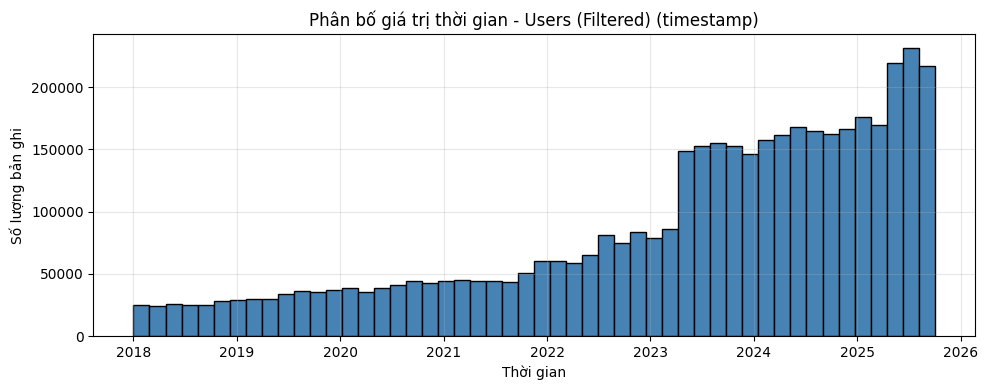

In [16]:
plot_timestamp_distribution(users_df, "timestamp", "Users (Filtered)")

In [18]:
import pandas as pd

# Chuyển cột install_date sang pandas datetime
ts = pd.to_datetime(users_df["install_date"].to_pandas(), unit='s', errors='coerce').dropna()

# Tính ngưỡng phân vị
q1, q99 = ts.quantile(0.01), ts.quantile(0.99)
print("Khoảng hợp lệ:", q1, "→", q99)

# Lọc theo khoảng
users_filtered = users_df.with_columns(
    pl.col("install_date").map_elements(
        lambda x: int(x) if q1.timestamp() <= x <= q99.timestamp() else None
    ).alias("install_date")
).drop_nulls("install_date")


Khoảng hợp lệ: 2018-06-02 00:00:00 → 2025-09-19 00:00:00


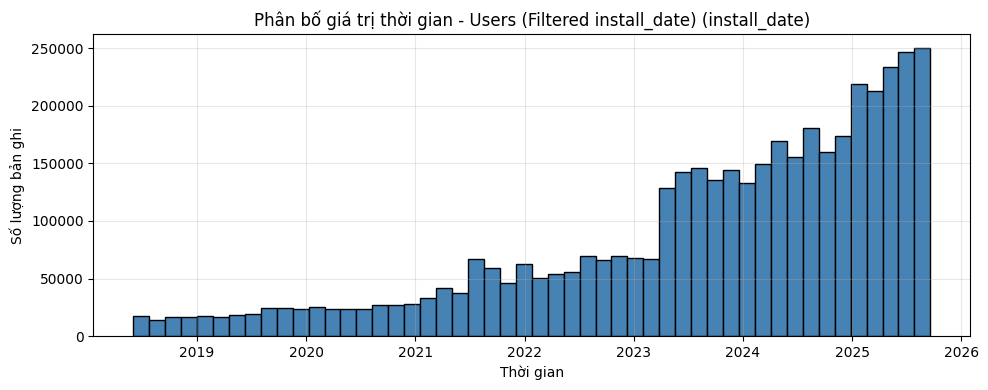

In [19]:
plot_timestamp_distribution(users_filtered, "install_date", "Users (Filtered install_date)")


In [9]:
def clip_outliers_iqr(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Giới hạn (clip) outlier của các cột bị lệch phải bằng IQR.
    """
    df_new = df.clone()
    for col in cols:
        if col not in df.columns:
            continue
        # Tính Q1, Q3, IQR
        q1 = df.select(pl.col(col).quantile(0.25)).item()
        q3 = df.select(pl.col(col).quantile(0.75)).item()
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        # Ghim giá trị vào khoảng hợp lệ
        df_new = df_new.with_columns(
            pl.when(pl.col(col) < lower).then(lower)
             .when(pl.col(col) > upper).then(upper)
             .otherwise(pl.col(col))
             .alias(col)
        )
    return df_new


# =========================
# Áp dụng cho các cột bị lệch phải
# =========================
right_skew_cols = ["price", "gp", "sale_status"]
items_df_clean = clip_outliers_iqr(items_df, right_skew_cols)


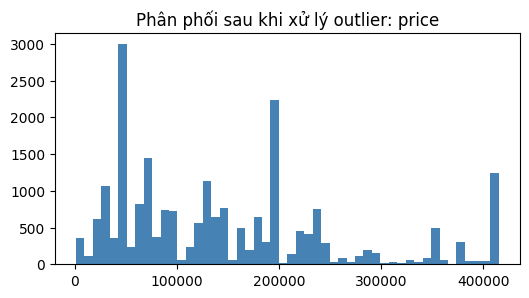

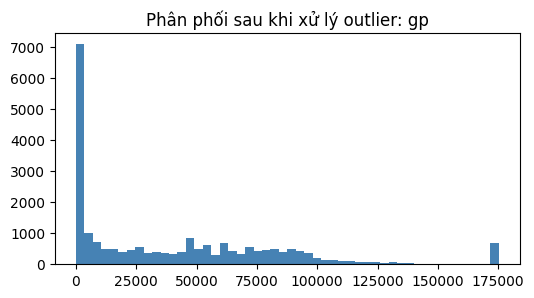

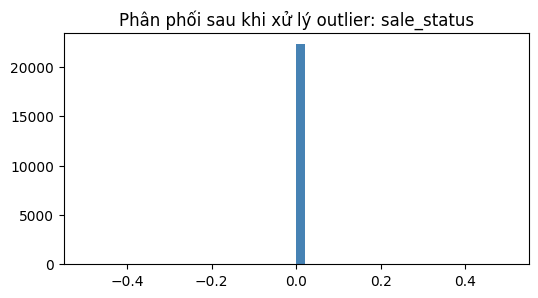

In [10]:
import matplotlib.pyplot as plt

for col in right_skew_cols:
    plt.figure(figsize=(6,3))
    plt.hist(items_df_clean[col].to_numpy(), bins=50, color='steelblue')
    plt.title(f"Phân phối sau khi xử lý outlier: {col}")
    plt.show()


## Task 3: Phân tích tương đồng và xác định xem các thuộc tính tương tự nhau. Từ đó loại bỏ đặc trưng thừa
**Mục tiêu:** Tìm các thuộc tính chứa thông tin trùng lặp/tương đương để loại bỏ, giúp mô hình gọn nhẹ, giảm đa cộng tuyến và cải thiện khả năng tổng quát hóa.

**Đầu vào:** `df` là **Polars DataFrame** sau Task 2 (đã xử lý NULL & Outlier).  
**Đầu ra chính:**
- `redundancy_report`: Bảng giải thích *vì sao* một cột bị đề xuất loại bỏ (metric, cột liên quan, %null, n_unique, ...).
- `redundant_cols`: Danh sách cột **đề xuất** loại.
- `df` sau khi loại bỏ `redundant_cols`.



In [8]:
# === Task 3: Chuẩn bị thư viện & tham số ===
import numpy as np
import pandas as pd
import polars as pl
from collections import defaultdict
from math import sqrt

# Tùy chọn: nếu có scipy/statsmodels sẽ dùng thêm; nếu thiếu, code vẫn chạy với nhánh dự phòng.
try:
    from scipy.stats import chi2_contingency
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    USE_VIF = True
except Exception:
    USE_VIF = False

# --- NGƯỠNG (có thể chỉnh theo EDA của nhóm) ---
PEARSON_THR = 0.90       # numeric-numeric: tương quan tuyến tính mạnh
SPEARMAN_THR = 0.95      # numeric-numeric: tương quan đơn điệu mạnh
CRAMER_V_THR = 0.90      # categorical-categorical
ETA_THR = 0.90           # categorical -> numeric (chỉ báo cáo)
VIF_THR = 10.0           # đa cộng tuyến mạnh

# Kiểm tra biến df tồn tại (Polars DataFrame)
assert 'df' in globals(), "Thiếu biến df (Polars DataFrame). Hãy chạy xong Task 2 trước."
assert isinstance(df, pl.DataFrame), "df phải là Polars DataFrame."
print(f"[INFO] df shape: {df.shape}")


[INFO] df shape: (27332, 32)


## Bước 1. Nhận diện kiểu dữ liệu & thống kê cơ bản

- Phân loại cột theo **numeric / categorical / datetime** (dựa vào dtype Polars).
- Tổng hợp một số metadata: số lượng null, tỉ lệ null, số giá trị phân biệt (n_unique).
- Mục đích: phục vụ tiêu chí chọn cột cần giữ/bỏ khi hai cột tương đương (ưu tiên giữ cột ít null hơn, đa dạng hơn).


In [9]:
# ==== BẢN TƯƠNG THÍCH NHIỀU VERSION POLARS ====
def _is_numeric_dtype(dt) -> bool:
    # Hỗ trợ Int/UInt/Float và Decimal(...)
    s = str(dt)
    return any(k in s for k in [
        "Int8", "Int16", "Int32", "Int64",
        "UInt8", "UInt16", "UInt32", "UInt64",
        "Float32", "Float64", "Decimal"
    ])

def _is_boolean_dtype(dt) -> bool:
    return "Boolean" in str(dt)

def _is_datetime_like(dt) -> bool:
    # Gồm Datetime(...), Date, Time, Duration
    s = str(dt)
    return any(k in s for k in ["Datetime", "Date", "Time", "Duration"])

def _is_categorical_like(dt) -> bool:
    # Utf8, Categorical, Enum
    s = str(dt)
    return any(k in s for k in ["Utf8", "Categorical", "Enum"])

def split_types_pl(df_pl: pl.DataFrame):
    """Phân loại cột theo kiểu dữ liệu (tương thích nhiều version Polars)."""
    num_cols, cat_cols, dt_cols, bool_cols = [], [], [], []
    for c, dt in zip(df_pl.columns, df_pl.dtypes):
        if _is_numeric_dtype(dt):
            num_cols.append(c)
        elif _is_boolean_dtype(dt):
            bool_cols.append(c)
        elif _is_datetime_like(dt):
            dt_cols.append(c)
        elif _is_categorical_like(dt):
            cat_cols.append(c)
        else:
            # fallback: nếu không nhận ra, tạm xem như categorical
            cat_cols.append(c)
    # Gộp boolean vào categorical vì thường hành xử như category
    cat_cols = sorted(set(cat_cols + bool_cols))
    return num_cols, cat_cols, dt_cols

# --- GỌI HÀM & TẠO METADATA ---
num_cols, cat_cols, dt_cols = split_types_pl(df)

df_pd = df.to_pandas()
meta = pd.DataFrame({
    'col': df_pd.columns,
    'n_null': df_pd.isna().sum().values,
    'pct_null': (df_pd.isna().mean() * 100).values,
    'n_unique': df_pd.nunique(dropna=True).values
}).sort_values('col')

print(f"[INFO] #Numeric: {len(num_cols)}, #Categorical: {len(cat_cols)}, #Datetime: {len(dt_cols)}")
meta.head(10)



[INFO] #Numeric: 11, #Categorical: 18, #Datetime: 3


,col,n_null,pct_null,n_unique
21,age_group,0,0.0,112
12,brand,0,0.0,976
10,category,0,0.0,1651
9,category_id,0,0.0,1833
4,category_l1,0,0.0,15
3,category_l1_id,0,0.0,15
6,category_l2,0,0.0,134
5,category_l2_id,0,0.0,139
8,category_l3,0,0.0,470
7,category_l3_id,0,0.0,523


In [10]:
# --- Ép nhóm *_id sang categorical để kiểm tra tương đồng (Cramér's V) ---
ID_HINTS = {"p_id", "user_id", "item_id",
            "category_id", "category_l1_id", "category_l2_id", "category_l3_id"}

# cột có hậu tố _id hoặc nằm trong ID_HINTS sẽ coi như categorical ở bước similarity
id_like_cols = [c for c in df.columns if c.endswith("_id") or c in ID_HINTS]

# cập nhật lại list kiểu (chỉ điều chỉnh CHO BƯỚC TƯƠNG ĐỒNG)
id_like_cols = [c for c in id_like_cols if c in num_cols]  # chỉ những cái đang bị coi là numeric
cat_cols = sorted(set(cat_cols + id_like_cols))
num_cols = [c for c in num_cols if c not in id_like_cols]

print("[INFO] treat as categorical for similarity:", id_like_cols)
print(f"[INFO] #Numeric: {len(num_cols)}, #Categorical: {len(cat_cols)}, #Datetime: {len(dt_cols)}")


[INFO] treat as categorical for similarity: ['p_id', 'category_l1_id', 'category_l2_id', 'category_l3_id', 'category_id', 'sync_status_id']
[INFO] #Numeric: 5, #Categorical: 24, #Datetime: 3


## Bước 2. Numeric–Numeric: Pearson & Spearman

- **Pearson** phát hiện tương quan **tuyến tính**.
- **Spearman** phát hiện tương quan **đơn điệu** (bền vững hơn với outlier/phi tuyến nhẹ).
- Với mỗi cặp numeric, nếu bất kỳ metric nào vượt ngưỡng, coi như **trùng thông tin mạnh**.


In [11]:
evidences = []

if len(num_cols) >= 2:
    # 1) Chỉ giữ những cột còn tồn tại trong df_pd
    num_cols_present = [c for c in num_cols if c in df_pd.columns]

    # 2) Ép kiểu numeric an toàn: non-numeric -> NaN
    num_block = df_pd[num_cols_present].apply(pd.to_numeric, errors='coerce')

    # 3) Loại các cột không đủ dữ liệu (toàn NaN) hoặc phương sai = 0
    valid_cols = []
    for c in num_block.columns:
        s = num_block[c].dropna()
        if s.size >= 2 and s.std(ddof=0) > 0:
            valid_cols.append(c)
    num_block = num_block[valid_cols]

    if len(valid_cols) >= 2:
        pearson = num_block.corr(method='pearson').abs()
        spearman = num_block.corr(method='spearman').abs()

        cols = list(num_block.columns)
        for i in range(len(cols)):
            for j in range(i+1, len(cols)):
                c1, c2 = cols[i], cols[j]
                # dùng .loc vì chắc chắn cột tồn tại trong ma trận
                pe = float(pearson.loc[c1, c2])
                sp = float(spearman.loc[c1, c2])
                if (pe >= PEARSON_THR) or (sp >= SPEARMAN_THR):
                    evidences.append(dict(kind='num-num',
                                          col1=c1, col2=c2,
                                          metric='pearson/spearman',
                                          value=max(pe, sp)))
    else:
        print("[WARN] Numeric block: số cột hợp lệ < 2 sau khi ép kiểu/loại hằng số -> bỏ qua bước tương quan.")
else:
    print("[INFO] Không đủ cột numeric để tính tương quan.")

pd.DataFrame([e for e in evidences if e['kind'] == 'num-num']).head(10)



""


**Ghi chú:** Một số cột như `price` có thể bị lưu thành `object` (do format, ký tự tiền tệ, hoặc giá trị lẫn ký tự).
Trong bước này, nhóm **ép kiểu numeric an toàn** (`errors='coerce'`), loại cột **toàn NaN** hoặc **phương sai = 0**,
rồi mới tính tương quan. Nhờ vậy tránh lỗi `KeyError` và đảm bảo kết quả phản ánh đúng các biến số có thông tin.


## Bước 3. Categorical–Categorical: Cramér's V (hiệu chỉnh bias)

- Đo độ kết hợp giữa 2 biến phân loại (0 → 1).
- Ngưỡng cao (≈ 0.90) xem như **trùng thông tin**.
- Nếu có `scipy`, dùng `chi2_contingency`; nếu không, fallback công thức gần đúng.


In [12]:
def cramers_v(ct_values: np.ndarray) -> float:
    # Nếu có scipy, dùng chuẩn
    if SCIPY_OK:
        chi2, _, _, _ = chi2_contingency(ct_values, correction=False)
    else:
        # Fallback rất đơn giản (không khuyến nghị bằng scipy, nhưng dùng tạm nếu thiếu)
        expected = ct_values.mean()
        chi2 = ((ct_values - expected) ** 2 / (expected + 1e-12)).sum()

    n = ct_values.sum()
    if n == 0:
        return 0.0
    r, k = ct_values.shape
    phi2 = chi2 / n
    # Bias correction (Bergsma, 2013)
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1 + 1e-9))
    rcorr = r - (r-1)**2/(n-1 + 1e-9)
    kcorr = k - (k-1)**2/(n-1 + 1e-9)
    denom = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return 0.0
    return float(sqrt(phi2corr / denom))

if len(cat_cols) >= 2:
    cat_pd = df_pd[cat_cols].astype('category')
    for i, c1 in enumerate(cat_cols):
        for c2 in cat_cols[i+1:]:
            try:
                ct = pd.crosstab(cat_pd[c1], cat_pd[c2])
                v = cramers_v(ct.values)
                if v >= CRAMER_V_THR:
                    evidences.append(dict(kind='cat-cat', col1=c1, col2=c2,
                                          metric='cramers_v', value=v))
            except Exception:
                pass

pd.DataFrame([e for e in evidences if e['kind']=='cat-cat']).head(10)


,kind,col1,col2,metric,value
0,cat-cat,category,category_id,cramers_v,0.983172
1,cat-cat,category,category_l1,cramers_v,0.958591
2,cat-cat,category,category_l1_id,cramers_v,0.958591
3,cat-cat,category,category_l2,cramers_v,0.944032
4,cat-cat,category,category_l2_id,cramers_v,0.941420
5,cat-cat,category,category_l3,cramers_v,0.922498
6,cat-cat,category,category_l3_id,cramers_v,0.909463
7,cat-cat,category_id,category_l1,cramers_v,0.966151
8,cat-cat,category_id,category_l1_id,cramers_v,0.966151
9,cat-cat,category_id,category_l2,cramers_v,0.968262


## Bước 4. Categorical → Numeric: Correlation Ratio (η)

- Đo mức độ biến numeric thay đổi theo nhóm của một biến categorical.


In [13]:
def correlation_ratio(categories, measurements) -> float:
    categories = pd.Series(categories)
    measurements = pd.Series(measurements)
    grp = measurements.groupby(categories, observed=True)
    n_total = measurements.count()
    if n_total == 0:
        return 0.0
    mean_total = measurements.mean()
    ss_between = sum(g.count() * (g.mean() - mean_total) ** 2 for _, g in grp)
    ss_total = ((measurements - mean_total) ** 2).sum()
    if ss_total == 0:
        return 0.0
    return float(np.sqrt(ss_between / ss_total))

eta_rows = []
for c_cat in cat_cols:
    for c_num in num_cols:
        try:
            eta = correlation_ratio(df_pd[c_cat], pd.to_numeric(df_pd[c_num], errors='coerce'))
            if eta >= ETA_THR:
                eta_rows.append(dict(kind='cat-num', col1=c_cat, col2=c_num, metric='eta', value=eta))
        except Exception:
            pass

# Thêm vào evidences nhưng sẽ không dùng để drop tự động
evidences.extend(eta_rows)

pd.DataFrame(eta_rows).sort_values('value', ascending=False).head(10)


,kind,col1,col2,metric,value
8,cat-num,p_id,price,eta,1.000000
7,cat-num,item_id,sale_status,eta,1.000000
11,cat-num,p_id,sale_status,eta,1.000000
4,cat-num,item_id,price,eta,1.000000
10,cat-num,p_id,gp,eta,1.000000
6,cat-num,item_id,gp,eta,1.000000
9,cat-num,p_id,creation_timestamp,eta,1.000000
5,cat-num,item_id,creation_timestamp,eta,1.000000
2,cat-num,description_new,price,eta,0.923114
0,cat-num,category,price,eta,0.914480


## Bước 5. Kiểm tra đa cộng tuyến khối số: VIF

- **VIF ≥ 10** thường được xem là đa cộng tuyến mạnh.
- Nếu thiếu `statsmodels` thì bước này sẽ bỏ qua (không lỗi notebook).


In [14]:
# === Cell 12 - VIF (bản an toàn) ===
vif_rows = []

if USE_VIF and len(num_cols) >= 2:
    # Chuẩn bị ma trận X numeric
    X = df_pd[num_cols].copy()

    # Ép kiểu numeric an toàn
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(X[c].median())

    # Loại cột hằng số (variance = 0) vì không tính VIF được
    keep = [c for c in X.columns if X[c].std(ddof=0) > 0]
    X = X[keep]

    if X.shape[1] >= 2:
        X = sm.add_constant(X, has_constant='add')
        try:
            vals = []
            for i in range(1, X.shape[1]):  # bỏ constant
                v = float(variance_inflation_factor(X.values, i))
                vals.append((X.columns[i], v))
                if v >= VIF_THR:
                    vif_rows.append(dict(kind='VIF', col=X.columns[i], metric='VIF', value=v))
        except Exception as e:
            print("[WARN] Lỗi khi tính VIF:", e)
    else:
        print("[INFO] Sau khi lọc hằng số, số cột numeric hợp lệ < 2 -> bỏ qua VIF.")
else:
    if not USE_VIF:
        print("[INFO] Bỏ qua VIF do thiếu statsmodels.")
    elif len(num_cols) < 2:
        print("[INFO] Không đủ cột numeric để tính VIF.")

# Hiển thị kết quả (tránh KeyError khi rỗng)
vif_df = pd.DataFrame(vif_rows)
if not vif_df.empty and 'value' in vif_df.columns:
    display(vif_df.sort_values('value', ascending=False))
else:
    print("[INFO] Không có biến nào vượt ngưỡng VIF hoặc không tính được VIF.")


[INFO] Bỏ qua VIF do thiếu statsmodels.
[INFO] Không có biến nào vượt ngưỡng VIF hoặc không tính được VIF.


In [15]:
# === Quy ước giữ/bỏ thống nhất của nhóm (Task 3) ===
SAFE_KEEP = {
    "creation_timestamp",   # GIỮ để Task 5 trích xuất đặc trưng theo thời gian
}

# Các khóa định danh: KHÔNG đưa vào X_train (có thể giữ trong DF để join/log)
SAFE_EXCLUDE_FROM_MODEL = {
    "p_id", "user_id", "item_id",
    "category_id", "category_l1_id", "category_l2_id", "category_l3_id"
}
    

## Bước 6. Tổng hợp bằng chứng & đề xuất cột loại bỏ

**Heuristic lựa chọn cột để loại khi có 2 cột tương đương:**
1) Bỏ cột có **%null cao hơn**,  
2) Nếu hòa, bỏ cột có **n_unique thấp hơn**,  
3) Nếu vẫn hòa, tie-break theo **tên cột** (giữ tên ngắn/dễ hiểu hơn).

**Lưu ý:**  
- Bằng chứng từ `num-num` & `cat-cat` và `VIF` dùng để đề xuất drop.  
- `eta` (cat→num) chỉ **báo cáo** để nhóm tự cân nhắc.


In [16]:
report_df = pd.DataFrame(evidences)

# Tạo tra cứu meta nhanh
meta_idx = meta.set_index('col')

def choose_to_drop(a, b):
    """
    Trả về tên cột nên DROP khi a và b tương đương.
    Quy tắc ưu tiên (đã thêm Rule-0 theo naming):
      Rule-0: Nếu là cặp cùng gốc và một bên là *_id => DROP label, GIỮ *_id.
      Rule-1: Bỏ cột có %null lớn hơn.
      Rule-2: Nếu hòa, bỏ cột có n_unique thấp hơn.
      Rule-3: Nếu vẫn hòa, bỏ theo tie-break tên (giữ tên ngắn/gọn hơn).
    """
    # Rule-0: Ưu tiên giữ *_id khi ghép cặp cùng gốc
    def base_name(col):
        # cắt hậu tố _id nếu có để so sánh cùng gốc
        return col[:-3] if col.endswith('_id') else col

    a_base, b_base = base_name(a), base_name(b)
    if a_base == b_base and (a.endswith('_id') ^ b.endswith('_id')):
        # một bên là *_id, một bên là label
        return a if not a.endswith('_id') else b  # DROP label, keep *_id

    # Lấy meta
    ma, mb = meta_idx.loc[a], meta_idx.loc[b]

    # Rule-1: %null — bỏ cột có %null cao hơn
    if ma['pct_null'] != mb['pct_null']:
        return a if ma['pct_null'] > mb['pct_null'] else b

    # Rule-2: n_unique — bỏ cột có n_unique thấp hơn
    if ma['n_unique'] != mb['n_unique']:
        return a if ma['n_unique'] < mb['n_unique'] else b

    # Rule-3: tie-break theo tên (bỏ tên "lớn" để giữ tên ngắn/gọn)
    return max(a, b)


scores = defaultdict(float)
reasons = defaultdict(list)

if not report_df.empty:
    for _, r in report_df.iterrows():
        kind = r['kind']
        if kind in ('num-num', 'cat-cat'):
            a, b = r['col1'], r['col2']
            drop = choose_to_drop(a, b)
            keep = b if drop == a else a
            scores[drop] += 1.0
            reasons[drop].append(f"{kind} high {r['metric']} with {keep} = {r['value']:.3f}")
        elif kind == 'VIF':
            c = r['col']
            scores[c] += 1.0
            reasons[c].append(f"High multicollinearity: VIF={r['value']:.1f}")
        # cat->num (eta) chỉ báo cáo, không cộng điểm

# Không drop các cột nằm trong SAFE_KEEP
for col in list(scores.keys()):
    if col in SAFE_KEEP:
        del scores[col]

# Danh sách đề xuất cuối (không chạm SAFE_KEEP)
redundant_cols = sorted([c for c, s in scores.items() if s >= 1.0 and c not in SAFE_KEEP])

print("[INFO] exclude_from_model (không đưa vào X_train):", sorted(SAFE_EXCLUDE_FROM_MODEL))


redundancy_report = pd.DataFrame({
    'column': redundant_cols,
    'score': [scores[c] for c in redundant_cols],
    'reason': ['; '.join(reasons[c]) for c in redundant_cols],
    'pct_null': [float(meta_idx.loc[c, 'pct_null']) for c in redundant_cols],
    'n_unique': [int(meta_idx.loc[c, 'n_unique']) for c in redundant_cols],
}).sort_values(['score','column'], ascending=[False, True]).reset_index(drop=True)

print(f"[INFO] Đề xuất loại {len(redundant_cols)} cột.")
redundancy_report.head(20)


[INFO] exclude_from_model (không đưa vào X_train): ['category_id', 'category_l1_id', 'category_l2_id', 'category_l3_id', 'item_id', 'p_id', 'user_id']
[INFO] Đề xuất loại 7 cột.


,column,score,reason,pct_null,n_unique
0,category_l1,7.0,cat-cat high cramers_v with category = 0.959; ...,0.0,15
1,category_l1_id,6.0,cat-cat high cramers_v with category = 0.959; ...,0.0,15
2,category_l2,5.0,cat-cat high cramers_v with category = 0.944; ...,0.0,134
3,category_l2_id,4.0,cat-cat high cramers_v with category = 0.941; ...,0.0,139
4,category_l3,3.0,cat-cat high cramers_v with category = 0.922; ...,0.0,470
5,category_l3_id,2.0,cat-cat high cramers_v with category = 0.909; ...,0.0,523
6,category,1.0,cat-cat high cramers_v with category_id = 0.983,0.0,1651


## Bước 7 — Áp dụng kết quả Task 3

**Mục tiêu:** dùng `redundancy_report` để chốt danh sách cột bỏ, đảm bảo thống nhất với EDA và nghiệp vụ.

### Cách đọc `redundancy_report`
- `column`: cột bị đề xuất bỏ.
- `reason`: bằng chứng (corr/Cramér’s V/VIF) và cột liên quan.
- `pct_null`, `n_unique`: tiêu chí ưu tiên giữ/bỏ khi hai cột tương đương.

### Nguyên tắc giữ/bỏ (nhóm thống nhất)
1. Giữ cột **ít thiếu** hơn (`pct_null` thấp).
2. Nếu hòa, giữ cột **đa dạng** hơn (`n_unique` cao).
3. Nếu vẫn hòa, giữ cột **ổn định/dễ encode** hơn (thường **giữ *_id**, bỏ label text).
4. **Khóa định danh** (`*_id`, `p_id`, `user_id`, `item_id`) **không dùng cho mô hình** → loại khỏi X_train (nhưng có thể giữ trong DF để join/log).

> `eta` (cat→num) và `MI` chỉ để **tham khảo**, **không** auto-drop.

### Bảng quyết định (điền ngắn gọn sau khi xem report)
| Cặp tương đồng                  | Giữ               | Bỏ            | Lý do | Metric |
|---------------------------------|-------------------|---------------|------|--------|
| category_id ↔ category          | category_id       | category      | giữ id ổn định, label gây nổ encode | V ≈ 1 |
| category_l1_id ↔ category_l1    | category_l1_id    | category_l1   | như trên | V ≈ 1 |
| category_l2_id ↔ category_l2    | category_l2_id    | category_l2   | như trên | V ≈ 1 |
| category_l3_id ↔ category_l3    | category_l3_id    | category_l3   | như trên | V ≈ 1 |
| p_id ↔ creation_timestamp       | creation_timestamp| p_id          | p_id là khóa; giữ time để feature   | r ≈ 1 |


In [17]:
# Sao lưu danh sách để truy vết (nếu muốn có thể lưu file JSON/CSV)
proposed_drop = redundant_cols.copy()
print("[INFO] proposed_drop:", proposed_drop)

df_before = df.shape
df = df.drop(proposed_drop)
df_after = df.shape

print(f"[DONE] df shape: trước {df_before} -> sau {df_after}")


[INFO] proposed_drop: ['category', 'category_l1', 'category_l1_id', 'category_l2', 'category_l2_id', 'category_l3', 'category_l3_id']
[DONE] df shape: trước (27332, 32) -> sau (27332, 25)
